3D_CloudFraction330m_201801_avg_CFMIP2_sat_3.1.2.nc


In [ ]:
import os
import requests
from datetime import datetime

# 基础 URL（根据你提供的链接）
base_url = "https://climserv.ipsl.polytechnique.fr/cfmip-obs/data/GOCCP_v3/3D_CloudFraction/grid_2x2xL40/2018/avg/"

# 文件名模板
# 第一种：3D_CloudFraction330m_YYYYMM_avg_CFMIP2_sat_3.1.2.nc
# 第二种：3D_CloudFraction_Phase330m_YYYYMM_avg_CFMIP2_sat_3.1.2.nc

# 创建保存目录
save_dir = "downloaded_nc"
os.makedirs(save_dir, exist_ok=True)

# 生成2018年1月到12月的月份列表
months = [f"2018{str(m).zfill(2)}" for m in range(2, 13)]

# 两种文件名前缀
prefixes = [
    "3D_CloudFraction330m",
    "3D_CloudFraction_Phase330m"
]

# 下载函数
def download_file(url, local_path):
    try:
        print(f"正在下载: {url}")
        response = requests.get(url, stream=True, timeout=30)
        response.raise_for_status()  # 检查HTTP错误
        with open(local_path, 'wb') as f:
            for chunk in response.iter_content(chunk_size=262144):
                f.write(chunk)
        print(f"保存成功: {local_path}")
    except Exception as e:
        print(f"下载失败 {url}: {e}")

# 遍历所有月份和前缀
for month in months:
    for prefix in prefixes:
        filename = f"{prefix}_{month}_avg_CFMIP2_sat_3.1.2.nc"
        file_url = base_url + filename
        local_file = os.path.join(save_dir, filename)
        # 如果文件已存在，跳过（可选）
        if not os.path.exists(local_file):
            download_file(file_url, local_file)
        else:
            print(f"文件已存在，跳过: {local_file}")

In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

df1 = xr.open_dataset(r"云量2018\3D_CloudFraction330m_201801_avg_CFMIP2_sat_3.1.2.nc")
df2 = xr.open_dataset(r"云相态2018\3D_CloudFraction_Phase330m_201801_avg_CFMIP2_sat_3.1.2.nc")

In [27]:
print(df1.info())#云量文件描述
print('--------------------------------')
print(df2.info())#云相态文件描述

xarray.Dataset {
dimensions:
	altitude = 40 ;
	nv = 2 ;
	time = 1 ;
	latitude = 90 ;
	longitude = 180 ;

variables:
	float32 alt_mid(altitude) ;
		alt_mid:long_name = Middle of the altitude bin ;
		alt_mid:units = kilometer ;
		alt_mid:positive = up ;
		alt_mid:axis = Z ;
	float32 alt_bound(nv, altitude) ;
		alt_bound:long_name = Boundaries of the altitude bin ;
		alt_bound:units = kilometer ;
	float32 clcalipso(time, altitude, latitude, longitude) ;
		clcalipso:long_name = CALIPSO 3D Cloud fraction ;
		clcalipso:units = 1 fraction ;
		clcalipso:cell_methods = time: mean ;
	float32 clrcalipso(time, altitude, latitude, longitude) ;
		clrcalipso:long_name = CALIPSO 3D Clear fraction ;
		clrcalipso:units = 1 fraction ;
		clrcalipso:cell_methods = time: mean ;
	float32 uncalipso(time, altitude, latitude, longitude) ;
		uncalipso:long_name = CALIPSO 3D Undefined fraction ;
		uncalipso:units = 1 fraction ;
		uncalipso:cell_methods = time: mean ;
	float32 longitude(longitude) ;
		longitude:lo

In [3]:
datasets=cal_cld_vertical(df1)
print(datasets[0][1].max())
print(datasets[1][1].max())
print(datasets[2][1].max())

<xarray.DataArray 'clcalipso' ()> Size: 8B
array(0.49926063)
Coordinates:
    time     datetime64[ns] 8B 2018-01-16
<xarray.DataArray 'clrcalipso' ()> Size: 8B
array(0.99999219)
Coordinates:
    time     datetime64[ns] 8B 2018-01-16
<xarray.DataArray 'uncalipso' ()> Size: 8B
array(0.17691223)
Coordinates:
    time     datetime64[ns] 8B 2018-01-16


垂直分布

已保存: test云量垂直\Cloud Fraction Vertical Distribution.png
已保存: test云量垂直\Clear Fraction Vertical Distribution.png
已保存: test云量垂直\Undefined Fraction Vertical Distribution.png


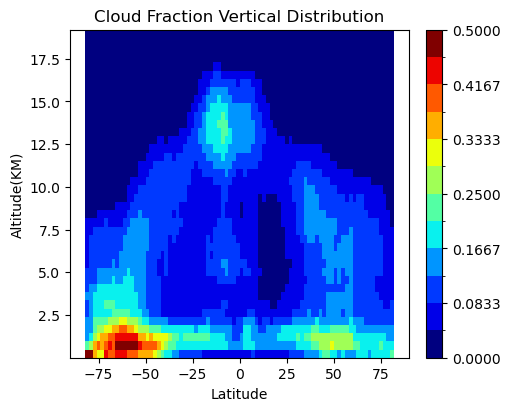

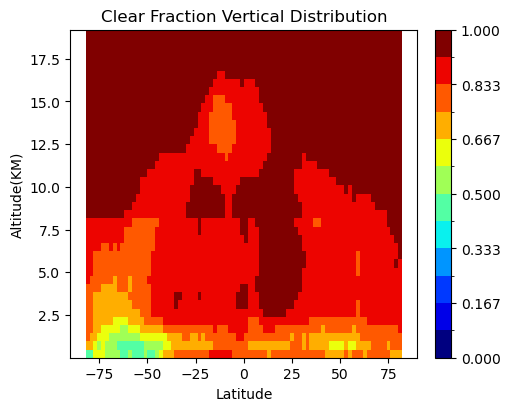

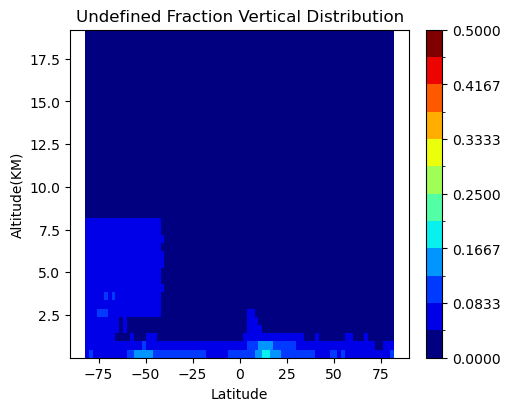

In [7]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import os
import glob


def cal_cld_vertical(ds):
    """计算全球云量的垂直分布：cloud、clear、uncalipso。

    Args:
        ds (xarray.Dataset): 包含'clcalipso'、'clrcalipso'和'uncalipso'变量的xarray数据集
    
    Returns:
        list of (title, data) tuples: 包含'cloud'、'clear'和'uncalipso'的垂直分布数据
    """
    Cloud = ds['clcalipso'].mean(dim=['longitude']).squeeze()#CALIPSO 3D Cloud fraction ;
    Clear = ds['clrcalipso'].mean(dim=['longitude']).squeeze()  #CALIPSO 3D Clear fraction ;
    uncalipso = ds['uncalipso'].mean(dim=['longitude']).squeeze()  #CALIPSO 3D Undefined fraction ;

    return [
        ('Cloud Fraction Vertical Distribution', Cloud),
        ('Clear Fraction Vertical Distribution', Clear),
        ('Undefined Fraction Vertical Distribution', uncalipso),
       
    ]

def plot_vertical_distribution(lat, alt,datasets,save_dir=None):
    """绘制云量的垂直分布图。

    args:
        latitude (xarray.DataArray): 包含纬度信息的xarray数据数组
        altitude ,给实参的时候给表示云层中心高度的 ds['alt_mid']
        datasets (list of (title, data) tuples): 包含标题和数据的列表
    returns:
        None
    """
    cmap='jet'
    bounds = [np.linspace(0, 0.5, 13),np.linspace(0,1,13)]
    norm = [mcolors.BoundaryNorm(boundaries=bounds[0], ncolors=256),
            mcolors.BoundaryNorm(boundaries=bounds[1], ncolors=256)]

    for idx,(title, data) in enumerate(datasets):

        fig,ax = plt.subplots(figsize=(5,4), constrained_layout=True)
        if idx != 1:
            cf1 = ax.pcolormesh(lat, alt, data, cmap=cmap, shading='auto', norm=norm[0])
        else:
            cf1 = ax.pcolormesh(lat, alt, data, cmap=cmap, shading='auto', norm=norm[1])
        ax.set_title(f'{title}')
        ax.set_xlabel('Latitude')
        ax.set_ylabel('Altitude(KM)')

        fig.colorbar(cf1, ax=ax, orientation='vertical'
                            )
        
        # fig, ax = plt.subplots(figsize=(7, 8))
        # levels = np.linspace(0, 1, 21)

        # cf = ax.contourf(
        #     df1["latitude"],      # X
        #     df1["alt_mid"],       # Y
        #     data,                # Z (2D)
        #     levels=levels,
        #     cmap="jet",
        #     extend="both"
        # )

        # ax.set_xlabel("Latitude")
        # ax.set_ylabel("Altitude (km)")
        # ax.set_title("Cloud Fraction Vertical Distribution")
        # plt.colorbar(cf, ax=ax, label="Cloud Fraction")
        

        # 自动保存
        if save_dir is not None:
            # 文件名中去除空格和特殊字符
            save_path = os.path.join(save_dir, f'{title}.png')
            fig.savefig(save_path, dpi=300)
            print(f'已保存: {save_path}')
        else:
            print('未指定保存目录，未保存图像。')

datasets = cal_cld_vertical(df1)
plot_vertical_distribution(df1['latitude'], df1['alt_mid'], datasets, save_dir='test云量垂直')



## 全球云量分布与垂直分布分析与可视化

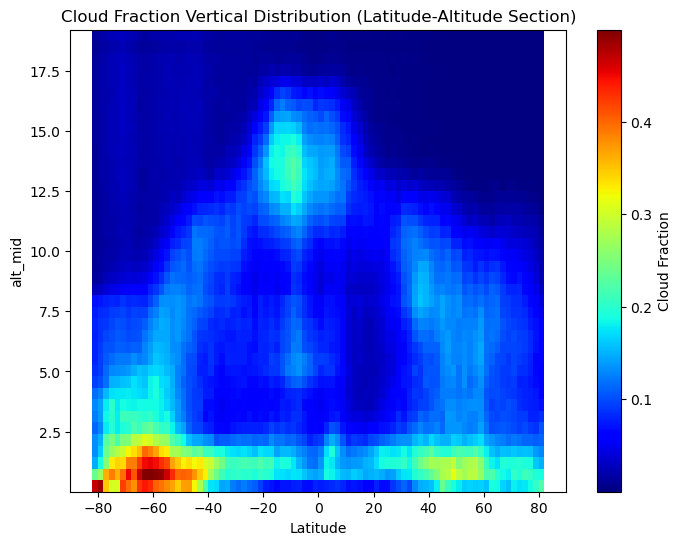

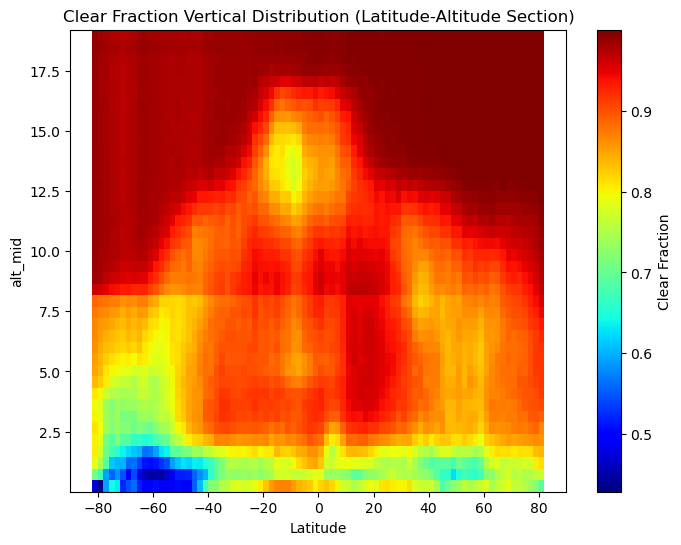

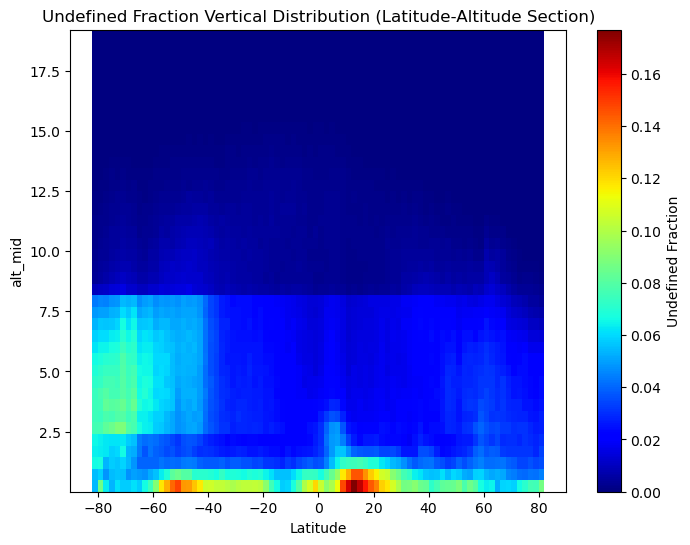

In [ ]:
# 2. 云量垂直分布（纬度-高度剖面，经度平均）
Cloud = df1['clcalipso'].mean(dim=['longitude']).squeeze()#CALIPSO 3D Cloud fraction ;
Clear = df1['clrcalipso'].mean(dim=['longitude']).squeeze()  #CALIPSO 3D Clear fraction ;
uncalipso = df1['uncalipso'].mean(dim=['longitude']).squeeze()  #CALIPSO 3D Undefined fraction ;
figure1 = plt.figure(figsize=(8,6))

plt.pcolormesh(df1['latitude'], df1['alt_mid'], Cloud, cmap='jet', shading='auto')
plt.colorbar(label='Cloud Fraction')
plt.title('Cloud Fraction Vertical Distribution (Latitude-Altitude Section)')
plt.xlabel('Latitude')
plt.ylabel('alt_mid')
plt.show()

figure2 = plt.figure(figsize=(8,6))
plt.pcolormesh(df1['latitude'], df1['alt_mid'], Clear, cmap='jet', shading='auto')
plt.colorbar(label='Clear Fraction')
plt.title('Clear Fraction Vertical Distribution (Latitude-Altitude Section)')
plt.xlabel('Latitude')
plt.ylabel('alt_mid')
plt.show()

figure3 = plt.figure(figsize=(8,6))
plt.pcolormesh(df1['latitude'], df1['alt_mid'], uncalipso, cmap='jet', shading='auto')
plt.colorbar(label='Undefined Fraction')
plt.title('Undefined Fraction Vertical Distribution (Latitude-Altitude Section)')
plt.xlabel('Latitude')
plt.ylabel('alt_mid')
plt.show()

AttributeError: 'list' object has no attribute 'cmap'

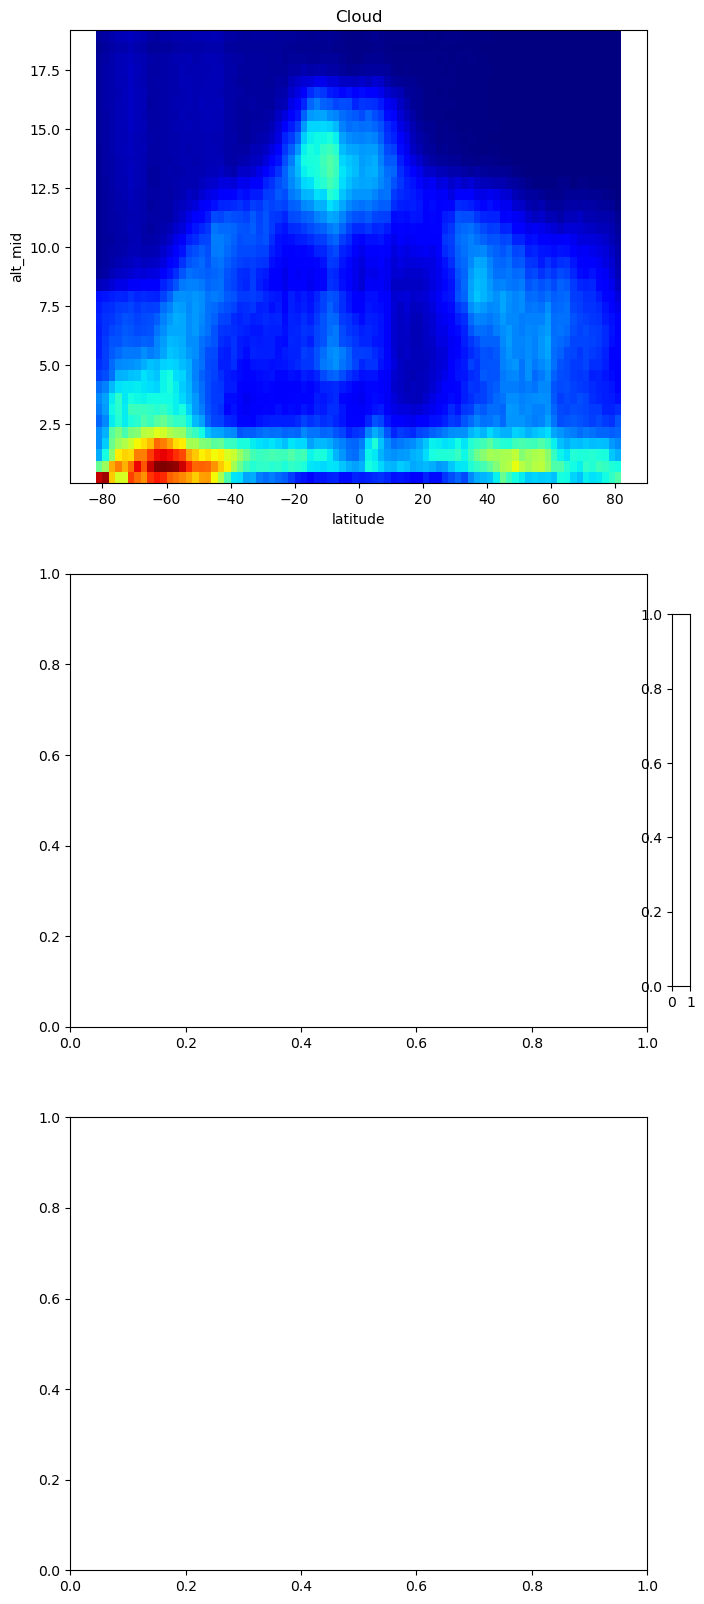

In [ ]:
fig, axes = plt.subplots(3,1, figsize=(8,20))
chunzhi = [Cloud, Clear, uncalipso]
titles = ['Cloud', 'Clear', 'Undefined']
ims = []

for i, (ax, data, title) in enumerate(zip(axes, chunzhi, titles)):
    # 注意pcolormesh的X、Y、C顺序，纬度为Y，经度为X，数据shape应为(lat, lon)
    im = ax.pcolormesh(df1['latitude'], df1['alt_mid'], data, cmap='jet', shading='auto')
    ax.set_title(title)
    ax.set_xlabel('latitude')
    
    ax.set_ylabel('alt_mid')
    cbar = fig.colorbar(ims[-1], ax=axes, orientation='vertical', fraction=0.03, pad=0.04, label=title)
    ims.append(im)

# 添加一个统一的色标

plt.tight_layout()
plt.show()

In [90]:
cld_zonal = df1['clcalipso'].mean(dim=['longitude']).squeeze()
print(np.isnan(cld_zonal.values).sum())
print(cld_zonal.values.size)
print(cld_zonal.max())
print(cld_zonal.min())

320
3600
<xarray.DataArray 'clcalipso' ()> Size: 8B
array(0.49926063)
Coordinates:
    time     datetime64[ns] 8B 2018-01-16
<xarray.DataArray 'clcalipso' ()> Size: 8B
array(7.79478432e-06)
Coordinates:
    time     datetime64[ns] 8B 2018-01-16


In [22]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

df1 = xr.open_dataset(r"云量18年\3D_CloudFraction330m_201801_avg_CFMIP2_sat_3.1.2.nc")
df2 = xr.open_dataset(r"云相态18\3D_CloudFraction_Phase330m_201801_avg_CFMIP2_sat_3.1.2.nc")

In [ ]:
print(df1['time'].dt.strftime('%Y-%m-%d').values[0])
ds = df1
if ds['time'].notnull().any():
    print(ds['time'].dt.strftime('%Y-%m-%d').values[0])
else:
    time_str = 'unknown_time'


2018-01-16
['2018-01-16T00:00:00.000000000']


In [23]:
def calc_cloud_layers(ds):
    """
    输入：ds（xarray.Dataset），需包含'clcalipso'和'alt_bound'变量
    返回：dict，包含低云、中云、高云、总云量的DataArray
    """
    up_bound = ds['alt_bound'][1].values
    low_idx = (up_bound < 2)
    mid_idx = (up_bound >= 2) & (up_bound < 7)
    high_idx = (up_bound >= 7)
    total_idx = (up_bound >= 0)
    cld_low = ds['clcalipso'].isel(altitude=low_idx).mean(dim='altitude').squeeze()
    cld_mid = ds['clcalipso'].isel(altitude=mid_idx).mean(dim='altitude').squeeze()
    cld_high = ds['clcalipso'].isel(altitude=high_idx).mean(dim='altitude').squeeze()
    cld_total = ds['clcalipso'].isel(altitude=total_idx).mean(dim='altitude').squeeze()
    return {
        'cld_low': cld_low,
        'cld_mid': cld_mid,
        'cld_high': cld_high,
        'cld_total': cld_total
    }

def get_cloud_datasets(ds):
    """
    输入：ds（xarray.Dataset），需包含'clcalipso'和'alt_bound'变量
    返回：[(title, data), ...]，用于分层云量可视化
    """
    layers = calc_cloud_layers(ds)
    cld_low,cld_mid,cld_high,cld_total = layers['cld_low'], layers['cld_mid'], layers['cld_high'], layers['cld_total']
    return [
        ('Low Cloud Fraction (0-2 km)', cld_low),
        ('Mid Cloud Fraction (2-7 km)', cld_mid),
        ('High Cloud Fraction (>=7 km)', cld_high),
        ('Total Cloud Fraction', cld_total),
    ]

# 用法
cloud_datasets = get_cloud_datasets(df1)

保存目录: 全球云量分布（经纬）\2018-01-16
已保存: 全球云量分布（经纬）\2018-01-16\Low_Cloud_Fraction_02_km.png
已保存: 全球云量分布（经纬）\2018-01-16\Mid_Cloud_Fraction_27_km.png
已保存: 全球云量分布（经纬）\2018-01-16\High_Cloud_Fraction_ge7_km.png
已保存: 全球云量分布（经纬）\2018-01-16\Total_Cloud_Fraction.png


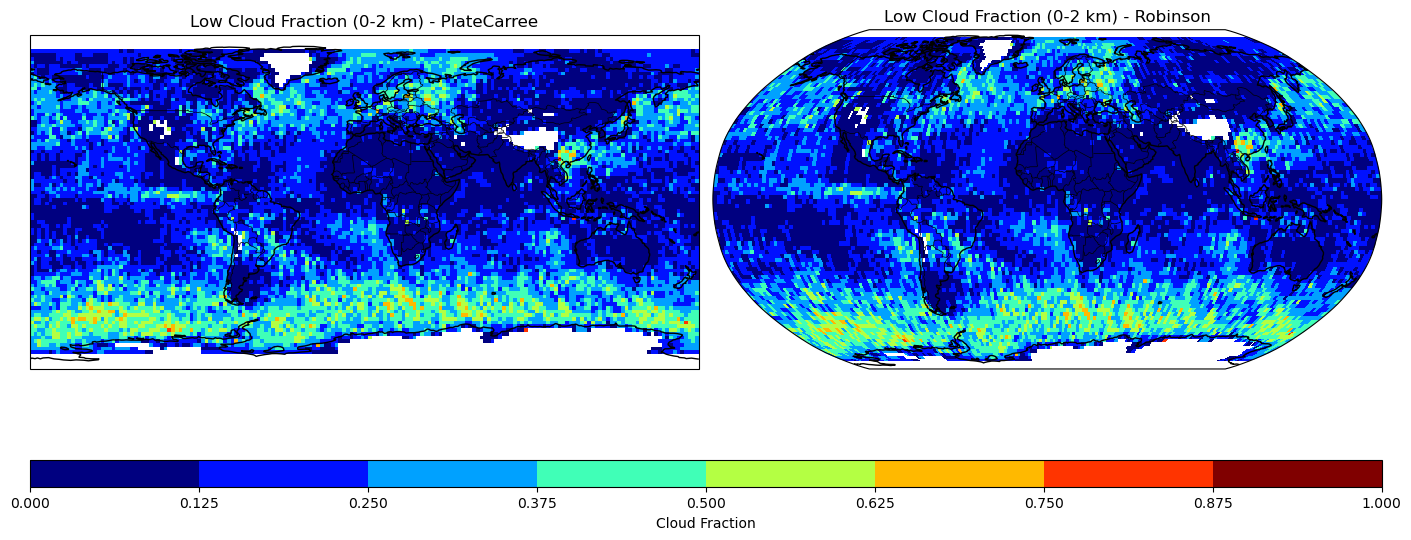

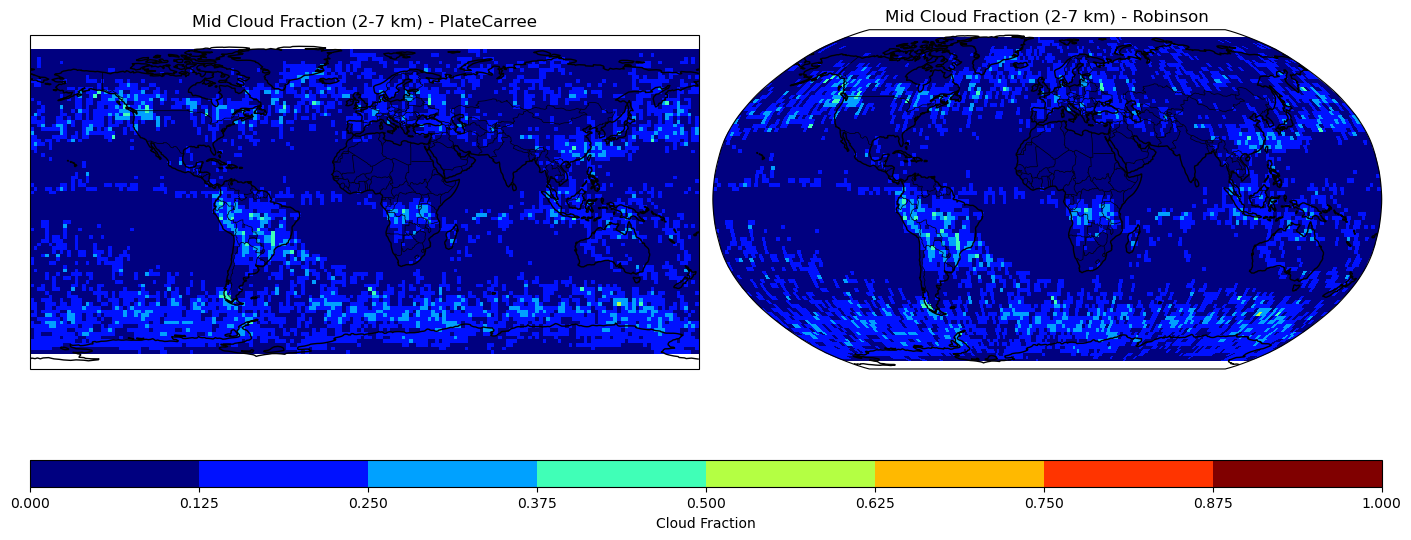

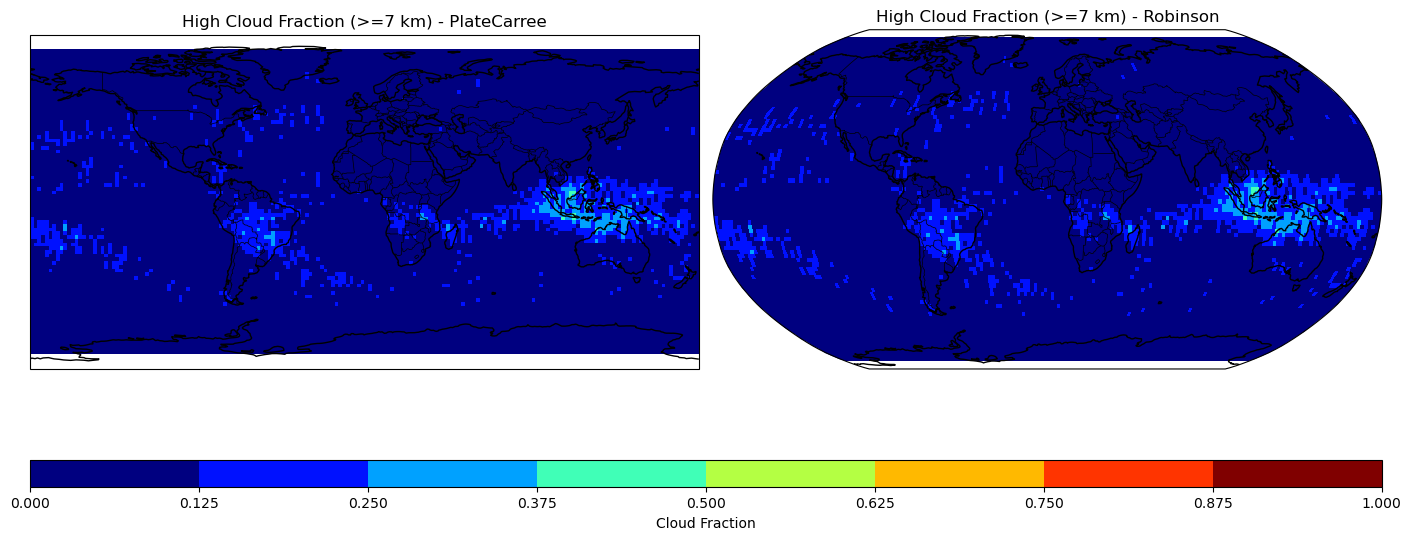

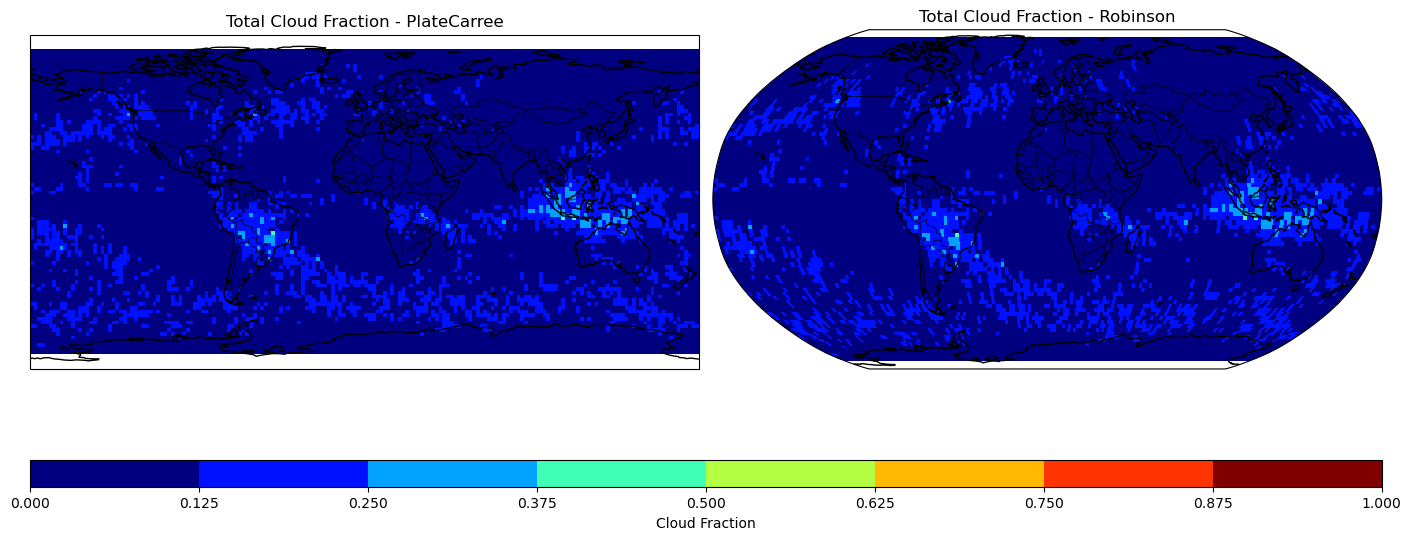

In [ ]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import os
def global_cloud_fraction_layout(lon, lat, datasets, cmap='jet', vmin=0, vmax=1,save_dir=None):
    """
    全球云量水平分布布局函数，支持多个云层数据的可视化。
    参数说明：
    datasets: list of (title, data) tuples.
    eg:
    cloud_datasets = [
    ('Low Cloud Fraction (0-2 km)', cld_low),
    ('Mid Cloud Fraction (2-7 km)', cld_mid),
    ('High Cloud Fraction (>=7 km)', cld_high),
    ('Total Cloud Fraction', cld_total),
    ]

    lon,lat:df1['longitude'], df1['latitude']
    cmap:颜色映射，vmin/vmax:色标范围
    """


    #绘图与保存
    figs = []
    bounds = np.linspace(vmin, vmax, 9)
    norm = mcolors.BoundaryNorm(boundaries=bounds, ncolors=256)

    for title, data in datasets:
        fig = plt.figure(figsize=(14, 6), constrained_layout=True)
        ax1 = fig.add_subplot(1, 2, 1, projection=ccrs.PlateCarree())
        ax2 = fig.add_subplot(1, 2, 2, projection=ccrs.Robinson())

        cf1 = ax1.pcolormesh(lon, lat, data, cmap=cmap, shading='auto', transform=ccrs.PlateCarree(), norm=norm)
        ax1.coastlines()
        ax1.add_feature(cfeature.BORDERS, linewidth=0.5)
        ax1.set_title(f'{title} - PlateCarree')
        ax1.set_xlabel('Longitude')
        ax1.set_ylabel('Latitude')

        cf2 = ax2.pcolormesh(lon, lat, data, cmap=cmap, shading='auto', transform=ccrs.PlateCarree(), norm=norm)
        ax2.coastlines()
        ax2.add_feature(cfeature.BORDERS, linewidth=0.5)
        ax2.set_title(f'{title} - Robinson')

        cbar = fig.colorbar(cf2, ax=[ax1, ax2], orientation='horizontal', fraction=0.07, pad=0.2,
                            aspect=50, label='Cloud Fraction')
        figs.append((fig, (ax1, ax2), cbar))
        

        # 自动保存
        if save_dir is not None:
            # 文件名中去除空格和特殊字符
            safe_title = title.replace(' ', '_').replace('(', '').replace(')', '').replace('>=', 'ge').replace('-', '').replace(',', '')
            save_path = os.path.join(save_dir, f'{safe_title}.png')
            fig.savefig(save_path, dpi=300)
            print(f'已保存: {save_path}')

    return figs

save_dir = '全球云量分布（经纬）'

#按时间创建文件夹，来保存图片
ds = df1
if ds['time'].notnull().any():
    time_str=ds['time'].dt.strftime('%Y-%m-%d').values[0]
else:
    time_str = 'unknown_time'

# 构建保存目录
if save_dir is not None:
    save_dir = os.path.join(save_dir,time_str) 
    os.makedirs(save_dir, exist_ok=True)
print(f"保存目录: {save_dir}")

#计算各云层数据
cloud_datasets = get_cloud_datasets(df1)
#绘图与保存
figs = global_cloud_fraction_layout(df1['longitude'], df1['latitude'], cloud_datasets, save_dir=save_dir)


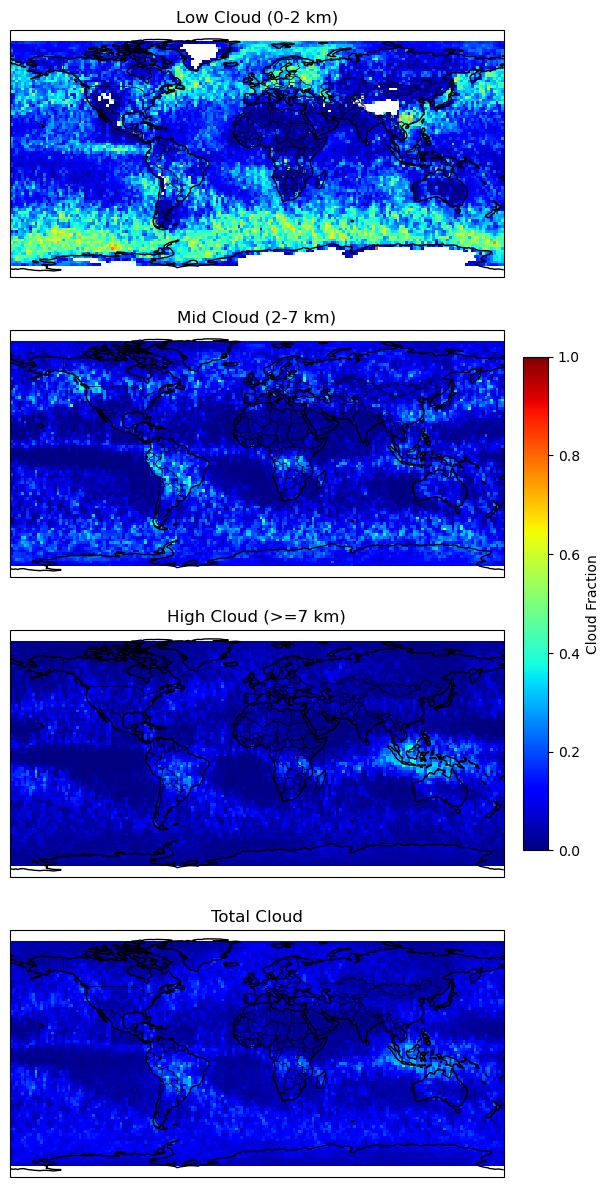

In [5]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig, axes = plt.subplots(4,1, figsize=(6,12), subplot_kw={'projection': ccrs.PlateCarree()},layout='constrained')
clouds = [cld_low, cld_mid, cld_high, total_idx]
titles = ['Low Cloud (0-2 km)', 'Mid Cloud (2-7 km)', 'High Cloud (>=7 km)', 'Total Cloud']
ims = []

for i, (ax, data, title) in enumerate(zip(axes, clouds, titles)):
    im = ax.pcolormesh(df1['longitude'], df1['latitude'], data, cmap='jet', shading='auto', vmin=0, vmax=1, transform=ccrs.PlateCarree())
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.set_title(title)
    ax.set_xlabel('Longitude')
    if i == 0:
        ax.set_ylabel('Latitude')
    ims.append(im)

# 添加一个统一的色标
cbar = fig.colorbar(ims[0], ax=axes, orientation='vertical', fraction=0.05, pad=0.04, label='Cloud Fraction')

plt.show()

In [51]:
import numpy as np

data = df1['clcalipso'].values
nan_count = np.isnan(data).sum()
total_count = data.size
print(f"缺失值数量: {nan_count}")
print(f"总元素数量: {total_count}")
print(f"缺失值比例: {nan_count / total_count:.2%}")

缺失值数量: 65701
总元素数量: 648000
缺失值比例: 10.14%
